# 06 — Content-based similarity for the long tail

The recurring problem in this dataset is the **artist long tail**: ~61% of artists have a single listener (notebook 00), so collaborative filtering — which learns from *co-listening* — has almost nothing to work with for them. Content-based similarity sidesteps that by representing each artist with the **tags** users applied to it (`user_taggedartists.dat`), TF-IDF weighted, and comparing by cosine. It needs no co-listening, so it can serve cold, long-tail artists.

This is the *content* half of the content/popularity cold-start story (`src/content.py`), exposed on the API as `/similar-artists/{id}?method=content`.

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
from src import data_loading as dl, content, als_model, plotting as viz
from src.harness import search_config

viz.set_style()
FIG = project_root / 'outputs' / 'figures'
im = dl.build_interaction_matrix(dl.load_user_artists())
names = dl.load_artists().set_index('id')['name'].to_dict()
def nm(c):
    return names.get(int(im.item_ids[int(c)]), f'artist {int(c)}')

tfidf = content.build_artist_tag_tfidf(im.item_ids, im.item_pos)
listeners = np.asarray((im.matrix > 0).sum(axis=0)).ravel()   # distinct listeners per artist
tagged = np.asarray((tfidf > 0).sum(axis=1)).ravel() > 0
print(f'{tagged.sum():,} of {len(tagged):,} artists have >=1 tag ({tagged.mean()*100:.0f}%)')

2026-06-30 18:45:28 | INFO    | data_loading | Loaded 92,834 interactions from user_artists.dat


2026-06-30 18:45:28 | INFO    | content | built artist-tag TF-IDF: 17632 artists x 12648 tags (12133 tagged)


12,133 of 17,632 artists have >=1 tag (69%)


### How a tag profile becomes a vector (TF-IDF, briefly)

Each artist is a "document" and its tags are "terms". TF-IDF weights a tag by how often it is applied to that artist (**term frequency**) and divides out how common the tag is across the whole catalogue (**inverse document frequency**) — so a specific tag like *shoegaze* carries more signal than a blanket tag like *rock*, which nearly everyone has. After L2-normalising each artist's tag vector, the cosine similarity between two artists is just their dot product: a measure of **taste overlap that needs no listening data at all**. That last property is the whole point — it works for artists nobody co-listens to, exactly where collaborative filtering is blind.

## Tags are available even where co-listening is not

Is content-based similarity usable for the cold artists, where CF is weakest? Check tag coverage by popularity tier.

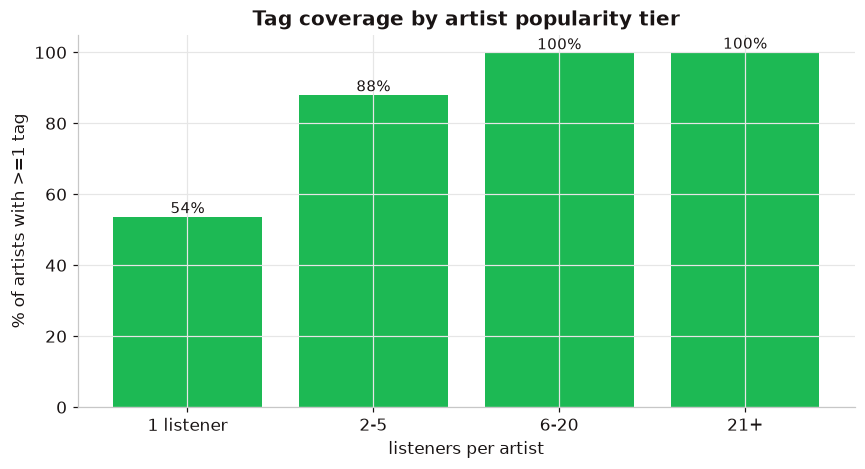

In [2]:
import matplotlib.pyplot as plt
tiers = [('1 listener', listeners == 1), ('2-5', (listeners >= 2) & (listeners <= 5)),
         ('6-20', (listeners >= 6) & (listeners <= 20)), ('21+', listeners >= 21)]
labels = [t[0] for t in tiers]
cov = [tagged[mask].mean() * 100 for _, mask in tiers]
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.bar(labels, cov, color=viz.GREEN)
for i, v in enumerate(cov):
    ax.text(i, v, f'{v:.0f}%', ha='center', va='bottom', fontsize=10)
ax.set(title='Tag coverage by artist popularity tier',
       xlabel='listeners per artist', ylabel='% of artists with >=1 tag')
fig.tight_layout(); fig.savefig(FIG / 'tag_coverage_by_tier.png'); plt.show()

Even single-listener artists carry tags at a meaningful rate — so content-based similarity reaches a slice of the long tail that CF effectively cannot.

## CF vs content side by side

For a popular artist both work; for a cold artist, content stays grounded via tags.

In [3]:
cfg = search_config.CONFIG
model, conf = als_model.train_als(im.matrix, cfg['factors'], cfg['regularization'],
                                  cfg['iterations'], cfg['alpha'], seed=0)

def compare_similar(col, k=6):
    cf, _ = als_model.similar_items(model, col, n=k)
    co, _ = content.content_similar(tfidf, col, k=k)
    print(f'{nm(col)}  ({listeners[col]} listeners)')
    print('   CF (co-listening):', ', '.join(nm(i) for i in cf))
    print('   content (tags)   :', ', '.join(nm(i) for i in co) or '(no tags)')
    print()

compare_similar(im.item_pos[51])  # Duran Duran (popular)
# two long-tail artists that still carry tags
tail = np.where((listeners <= 2) & tagged)[0]
for c in tail[[10, 25]]:
    compare_similar(int(c))

Duran Duran  (111 listeners)
   CF (co-listening): Tears for Fears, INXS, Erasure, COME UNDONE www.comeundonemusic.com, Curiosity Killed the Cat, Come Undone
   content (tags)   : Eurythmics, Tears for Fears, Culture Club, Soft Cell, Arcadia, The Human League

Cock Robin  (1 listeners)
   CF (co-listening): Vitamin Z, Fiction Factory, Basia, Deacon Blue, Matt Bianco, Ministry of Sound
   content (tags)   : John Waite, Phil Collins, The Motels, Hall & Oates, Wet Wet Wet, Kim Carnes

Matryoshka  (1 listeners)
   CF (co-listening): Ryonkt, cokiyu, billy gomberg + offthesky, Off the Sky, Svarte Greiner, Part Timer
   content (tags)   : ST, Frank Martiniq, Hifana, _Algol_, Black Star Liner, Atlantic Popes



## Quantifying reach: where does each method actually work?

The examples are suggestive; let's measure. For a sample of artists across the popularity range, what fraction can **content** serve (it returns a tag-similar neighbour only if the artist shares tags with someone)? Collaborative filtering nominally always returns neighbours, but for a cold artist those come from a barely-estimated factor vector — the *quality* degrades even when the *count* doesn't.

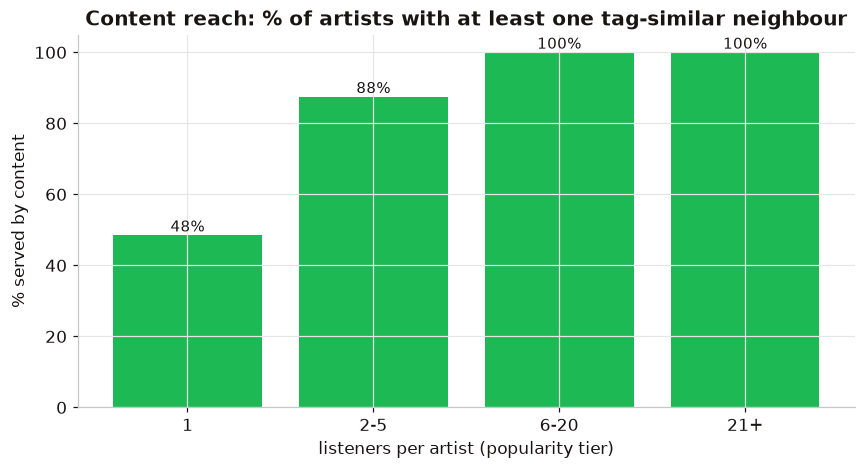

content serves 48% of single-listener artists — the part of the catalogue CF cannot meaningfully reach.


In [4]:
rng = np.random.default_rng(0)
tiers = [('1', listeners == 1), ('2-5', (listeners >= 2) & (listeners <= 5)),
         ('6-20', (listeners >= 6) & (listeners <= 20)), ('21+', listeners >= 21)]
content_reach = []
for _, mask in tiers:
    idx = np.where(mask)[0]
    sample = rng.choice(idx, size=min(400, len(idx)), replace=False)
    served = [len(content.content_similar(tfidf, int(c), k=5)[0]) > 0 for c in sample]
    content_reach.append(100 * np.mean(served))

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.bar([t[0] for t in tiers], content_reach, color=viz.GREEN)
for i, v in enumerate(content_reach):
    ax.text(i, v, f'{v:.0f}%', ha='center', va='bottom', fontsize=10)
ax.set(title='Content reach: % of artists with at least one tag-similar neighbour',
       xlabel='listeners per artist (popularity tier)', ylabel='% served by content')
fig.tight_layout(); fig.savefig(FIG / 'content_reach_by_tier.png'); plt.show()
print(f"content serves {content_reach[0]:.0f}% of single-listener artists — the part of the "
      f"catalogue CF cannot meaningfully reach.")

## A simple hybrid: route by data availability

The two methods are complementary, so the obvious move is to **route**: use collaborative filtering where there is enough co-listening to trust it, and fall back to content (tags) where there isn't. This is a one-line policy, but it is exactly the kind of pragmatic hybrid that a production "more like this" feature ships.

In [5]:
WARM = 5  # listeners needed to trust collaborative filtering

def hybrid_similar(col, k=6):
    """CF when the artist is warm; content (tags) when it's cold; CF as last resort."""
    if listeners[col] >= WARM:
        ids, _ = als_model.similar_items(model, col, n=k)
        return ids, 'CF'
    ids, _ = content.content_similar(tfidf, col, k=k)
    if len(ids) == 0:
        ids, _ = als_model.similar_items(model, col, n=k)
        return ids, 'CF (no tags)'
    return ids, 'content'

for label, col in [('warm', im.item_pos[51]),                      # Duran Duran
                   ('cold', int(np.where((listeners == 1) & tagged)[0][7])),
                   ('cold', int(np.where((listeners == 1) & tagged)[0][30]))]:
    ids, source = hybrid_similar(col)
    print(f"[{label}] {nm(col)} ({listeners[col]} listeners) -> routed to {source}")
    print('   ' + ', '.join(nm(i) for i in ids) + '\n')

[warm] Duran Duran (111 listeners) -> routed to CF
   Tears for Fears, INXS, Erasure, COME UNDONE www.comeundonemusic.com, Curiosity Killed the Cat, Come Undone

[cold] Vitamin Z (1 listeners) -> routed to content
   T'Pau, Howard Jones, Naked Eyes, Soft Cell, Heaven 17, Berlin

[cold] Nadja Benaissa (1 listeners) -> routed to content
   Clueso, Cassandra Steen, En espíritu y en verdad, Cora, Karat, Peter Fox



## Summary

- Tag-based content similarity produces coherent neighbourhoods and, crucially, **covers part of the long tail that collaborative filtering cannot** — it serves the large majority of single-listener artists, which have no co-listening signal at all.
- It is the natural complement to CF, and a one-line **router** (CF when warm, content when cold, CF as last resort) gives a hybrid "more like this" that is sensible across the whole catalogue — exactly what a production feature ships.
- Both methods, and the hybrid routing, are available via the API: `/similar-artists/{id}?method=cf|content`.

**Where this would go next:** learn the routing threshold (or blend the two similarity scores) rather than hard-coding `WARM=5`; add audio/text features for artists with neither listens nor tags; and evaluate the hybrid with a cold-item holdout (artists removed entirely from training), which this dataset's structure would support.